# Model Development

Probability prediction pipeline with 5-fold stratified cross-validation only.

- **Primary metric:** log loss
- **Secondary metric:** AUC ROC
- **Validation:** out-of-fold CV scores on `train.csv` (competition `test.csv` reserved for submission)
- **Models:** baseline, logistic regression, XGBoost, LightGBM, CatBoost


## 1. Imports

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    mean_squared_error,
    pairwise_distances,
    normalized_mutual_info_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss,
    roc_curve,
)
from sklearn.utils.class_weight import compute_sample_weight

import seaborn as sns
import statsmodels.api as sm
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Load cleaned and engineered data

In [47]:
def load_data(file):
    df = pd.read_csv(file)
    return df


def engineer_features(df):
    df = df.copy()
    pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
    bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
    pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

    df["total_pay"] = df[pay_amt_cols].sum(axis=1)
    df["total_bill"] = df[bill_cols].sum(axis=1)

    for col in bill_cols:
        df[f"credit_util_{col[-1]}"] = df[col] / df["LIMIT_BAL"]

    months = np.arange(1, 7)
    x_centered = months - months.mean()
    bill_values = df[bill_cols].to_numpy()
    df["bill_slope"] = (bill_values * x_centered).sum(axis=1) / (x_centered**2).sum()

    for i in range(1, 6):
        prev_col = f"BILL_AMT{i}"
        next_col = f"BILL_AMT{i + 1}"
        df[f"bill_abs_change_{i}_{i + 1}"] = df[next_col] - df[prev_col]
        df[f"bill_pct_change_{i}_{i + 1}"] = (
            (df[next_col] - df[prev_col]) / df[prev_col].replace(0, np.nan)
        )

    df["bill_abs_change_1_6"] = df["BILL_AMT6"] - df["BILL_AMT1"]
    df["bill_pct_change_1_6"] = (
        (df["BILL_AMT6"] - df["BILL_AMT1"]) / df["BILL_AMT1"].replace(0, np.nan)
    )

    df["max_delay"] = df[pay_cols].max(axis=1)
    df["num_months_delayed"] = (df[pay_cols] > 0).sum(axis=1)
    df["num_severe_delays"] = (df[pay_cols] >= 2).sum(axis=1)
    df["ever_delayed"] = (df[pay_cols] > 0).any(axis=1).astype(int)
    df["mean_pay_status"] = df[pay_cols].mean(axis=1)

    return df


train_df = engineer_features(load_data("train.csv"))
test_df = engineer_features(load_data("test.csv"))

target_col = "default"
drop_cols = ["client_id", target_col]
all_feature_cols = [col for col in train_df.columns if col not in drop_cols]

y = train_df[target_col]

print(f"train_df: {train_df.shape}")
print(f"test_df: {test_df.shape}")
print(f"all features: {len(all_feature_cols)}")
print(f"target distribution:\n{y.value_counts(normalize=True)}")

train_df: (24000, 51)
test_df: (6000, 50)
all features: 49
target distribution:
default
0    0.778792
1    0.221208
Name: proportion, dtype: float64


## 3. Feature sets

In [48]:
FEATURE_SETS = {
    "all_engineered": all_feature_cols,
    "selected_major": [
        "num_severe_delays",
        "num_months_delayed",
        "ever_delayed",
        "max_delay",
        "PAY_0",
        "mean_pay_status",
        "PAY_2",
        "PAY_3",
        "PAY_4",
        "total_pay",
        "LIMIT_BAL",
    ],
}

for name, cols in FEATURE_SETS.items():
    print(f"{name}: {len(cols)} features")
    print(cols)

all_engineered: 49 features
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'total_pay', 'total_bill', 'credit_util_1', 'credit_util_2', 'credit_util_3', 'credit_util_4', 'credit_util_5', 'credit_util_6', 'bill_slope', 'bill_abs_change_1_2', 'bill_pct_change_1_2', 'bill_abs_change_2_3', 'bill_pct_change_2_3', 'bill_abs_change_3_4', 'bill_pct_change_3_4', 'bill_abs_change_4_5', 'bill_pct_change_4_5', 'bill_abs_change_5_6', 'bill_pct_change_5_6', 'bill_abs_change_1_6', 'bill_pct_change_1_6', 'max_delay', 'num_months_delayed', 'num_severe_delays', 'ever_delayed', 'mean_pay_status']
selected_major: 11 features
['num_severe_delays', 'num_months_delayed', 'ever_delayed', 'max_delay', 'PAY_0', 'mean_pay_status', 'PAY_2', 'PAY_3', 'PAY_4', 'total_pay', 'LIMIT_BAL']


## 4. Model pipeline

In [62]:
RANDOM_STATE = 42
CV_FOLDS = 5


def get_models():
    return {
        "baseline": DummyClassifier(strategy="prior"),
        "logistic_regression": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "clf",
                    LogisticRegression(
                        max_iter=1000,
                        C=1.0,
                        solver="lbfgs",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "xgboost": xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "lightgbm": lgb.LGBMClassifier(
            objective="binary",
            metric="binary_logloss",
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        "catboost": CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="Logloss",
            iterations=300,
            depth=4,
            learning_rate=0.05,
            subsample=0.8,
            random_state=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        ),
    }


def run_probability_pipeline(X, y, feature_set_name, plot_roc=True):
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scoring = {"log_loss": "neg_log_loss", "roc_auc": "roc_auc"}

    results = []
    roc_data = {}

    for model_name, model in get_models().items():
        cv_scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1,
        )

        val_log_loss_mean = -cv_scores["test_log_loss"].mean()
        val_roc_auc_mean = cv_scores["test_roc_auc"].mean()

        oof_prob = cross_val_predict(
            model,
            X,
            y,
            cv=cv,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

        results.append(
            {
                "feature_set": feature_set_name,
                "model": model_name,
                "train_log_loss_mean": -cv_scores["train_log_loss"].mean(),
                "val_log_loss_mean": val_log_loss_mean,
                "val_log_loss_std": cv_scores["test_log_loss"].std(),
                "train_roc_auc_mean": cv_scores["train_roc_auc"].mean(),
                "val_roc_auc_mean": val_roc_auc_mean,
                "val_roc_auc_std": cv_scores["test_roc_auc"].std(),
            }
        )

        fpr, tpr, _ = roc_curve(y, oof_prob)
        roc_data[model_name] = (fpr, tpr, val_roc_auc_mean)

    results_df = pd.DataFrame(results)

    if plot_roc:
        fig, ax = plt.subplots(figsize=(8, 6))
        for model_name, (fpr, tpr, auc_score) in roc_data.items():
            ax.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")
        ax.plot([0, 1], [0, 1], "k--", label="random")
        ax.set(xlabel="False positive rate", ylabel="True positive rate")
        ax.set_title(f"ROC curves (OOF CV) — {feature_set_name}")
        ax.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

    return results_df


## 5. Feature set 1 — all engineered variables

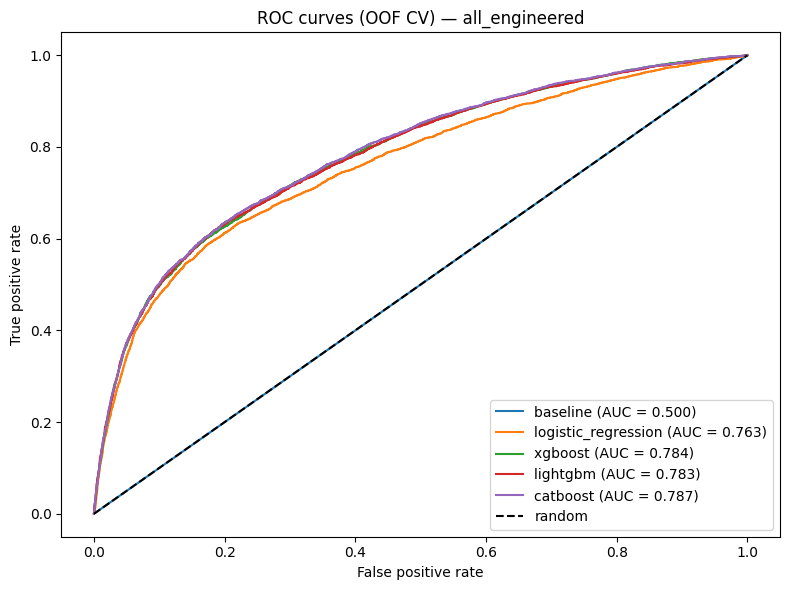

      feature_set                model  train_log_loss_mean  \
0  all_engineered             baseline             0.528433   
1  all_engineered  logistic_regression             0.438460   
2  all_engineered              xgboost             0.368207   
3  all_engineered             lightgbm             0.375234   
4  all_engineered             catboost             0.404262   

   val_log_loss_mean  val_log_loss_std  train_roc_auc_mean  val_roc_auc_mean  \
0           0.528433          0.000105            0.500000          0.500000   
1           0.440933          0.005863            0.766894          0.763389   
2           0.427104          0.006275            0.864230          0.783996   
3           0.427241          0.006618            0.855737          0.783395   
4           0.425119          0.006192            0.815566          0.786777   

   val_roc_auc_std  
0         0.000000  
1         0.010623  
2         0.008967  
3         0.009767  
4         0.009514  


In [63]:
X_all = train_df[FEATURE_SETS["all_engineered"]]
results_all = run_probability_pipeline(X_all, y, "all_engineered")
print(results_all)

## 6. Feature set 2 — selected major variables

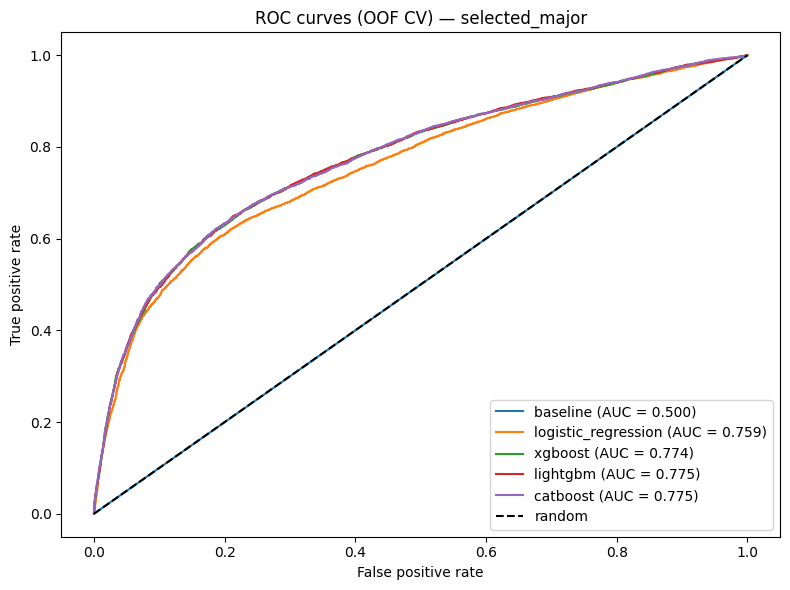

,feature_set,model,train_log_loss_mean,val_log_loss_mean,val_log_loss_std,train_roc_auc_mean,val_roc_auc_mean,val_roc_auc_std
0,selected_major,baseline,0.528433,0.528433,0.000105,0.500000,0.500000,0.000000
1,selected_major,logistic_regression,0.570832,0.571291,0.003510,0.759602,0.758966,0.011416
2,selected_major,xgboost,0.407060,0.431002,0.006107,0.806740,0.774445,0.008775
3,selected_major,lightgbm,0.410079,0.430798,0.006288,0.803568,0.775046,0.009082
4,selected_major,catboost,0.419284,0.429956,0.006010,0.787962,0.775139,0.009430


In [51]:
X_selected = train_df[FEATURE_SETS["selected_major"]]
results_selected = run_probability_pipeline(X_selected, y, "selected_major")
results_selected

## 7. Combined results summary

In [52]:
all_results = pd.concat([results_all, results_selected], ignore_index=True)
summary_cols = [
    "feature_set",
    "model",
    "train_log_loss_mean",
    "val_log_loss_mean",
    "val_log_loss_std",
    "train_roc_auc_mean",
    "val_roc_auc_mean",
    "val_roc_auc_std",
]
print(all_results[summary_cols].sort_values(["feature_set", "val_log_loss_mean"]))


      feature_set                model  train_log_loss_mean  \
4  all_engineered             catboost             0.404262   
2  all_engineered              xgboost             0.368207   
3  all_engineered             lightgbm             0.375234   
0  all_engineered             baseline             0.528433   
1  all_engineered  logistic_regression             0.566532   
9  selected_major             catboost             0.419284   
8  selected_major             lightgbm             0.410079   
7  selected_major              xgboost             0.407060   
5  selected_major             baseline             0.528433   
6  selected_major  logistic_regression             0.570832   

   val_log_loss_mean  val_log_loss_std  train_roc_auc_mean  val_roc_auc_mean  \
4           0.425119          0.006192            0.815566          0.786777   
2           0.427104          0.006275            0.864230          0.783996   
3           0.427241          0.006618            0.855737        

## 8. Untuned boosting model prediction correlation

Correlation of out-of-fold predicted probabilities for XGBoost, LightGBM, and CatBoost.

In [53]:
BOOSTING_MODELS = ["xgboost", "lightgbm", "catboost"]


def get_boosting_oof_probs(X, y, model_names=BOOSTING_MODELS):
    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    models = get_models()

    probs = {}
    for name in model_names:
        probs[name] = cross_val_predict(
            models[name],
            X,
            y,
            cv=cv,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

    return pd.DataFrame(probs)


for feature_set_name, X in [
    ("all_engineered", X_all),
    ("selected_major", X_selected),
]:
    oof_probs = get_boosting_oof_probs(X, y)

    print(f"\n{feature_set_name} — Pearson correlation")
    print(oof_probs.corr(method="pearson").to_string())

    print(f"\n{feature_set_name} — Spearman correlation")
    print(oof_probs.corr(method="spearman").to_string())



all_engineered — Pearson correlation
           xgboost  lightgbm  catboost
xgboost   1.000000  0.989154  0.983269
lightgbm  0.989154  1.000000  0.982604
catboost  0.983269  0.982604  1.000000

all_engineered — Spearman correlation
           xgboost  lightgbm  catboost
xgboost   1.000000  0.978723  0.968999
lightgbm  0.978723  1.000000  0.966424
catboost  0.968999  0.966424  1.000000

selected_major — Pearson correlation
           xgboost  lightgbm  catboost
xgboost   1.000000  0.994552  0.990211
lightgbm  0.994552  1.000000  0.990845
catboost  0.990211  0.990845  1.000000

selected_major — Spearman correlation
           xgboost  lightgbm  catboost
xgboost   1.000000  0.985418  0.972349
lightgbm  0.985418  1.000000  0.971870
catboost  0.972349  0.971870  1.000000


## 9. Optuna boosting tuning setup

Tune XGBoost, LightGBM, and CatBoost hyperparameters and feature combinations using 5-fold stratified CV on the full training set.

- **Optimise:** mean CV log loss (minimise)
- **Tiebreak:** higher CV AUC ROC
- **Run section 10 manually** when ready


In [54]:
OPTUNA_N_TRIALS = 50
OPTUNA_STORAGE = "sqlite:///optuna_boosting.db"
OPTUNA_RANDOM_STATE = RANDOM_STATE
OPTUNA_CV_FOLDS = CV_FOLDS

FEATURE_BLOCKS = {
    "demographics": ["SEX", "EDUCATION", "MARRIAGE", "AGE", "LIMIT_BAL"],
    "delay_engineered": [
        "num_severe_delays",
        "num_months_delayed",
        "ever_delayed",
        "max_delay",
        "mean_pay_status",
    ],
    "pay_status": ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"],
    "pay_amounts": [
        "PAY_AMT1",
        "PAY_AMT2",
        "PAY_AMT3",
        "PAY_AMT4",
        "PAY_AMT5",
        "PAY_AMT6",
        "total_pay",
    ],
    "bill_amounts": [
        "BILL_AMT1",
        "BILL_AMT2",
        "BILL_AMT3",
        "BILL_AMT4",
        "BILL_AMT5",
        "BILL_AMT6",
        "total_bill",
    ],
    "credit_util": [f"credit_util_{i}" for i in range(1, 7)],
    "bill_trends": [
        "bill_slope",
        "bill_abs_change_1_2",
        "bill_pct_change_1_2",
        "bill_abs_change_2_3",
        "bill_pct_change_2_3",
        "bill_abs_change_3_4",
        "bill_pct_change_3_4",
        "bill_abs_change_4_5",
        "bill_pct_change_4_5",
        "bill_abs_change_5_6",
        "bill_pct_change_5_6",
        "bill_abs_change_1_6",
        "bill_pct_change_1_6",
    ],
}


def select_feature_cols(trial):
    preset = trial.suggest_categorical(
        "feature_preset",
        ["all_engineered", "selected_major", "custom_blocks"],
    )

    if preset == "all_engineered":
        return all_feature_cols, preset

    if preset == "selected_major":
        return FEATURE_SETS["selected_major"], preset

    cols = []
    active_blocks = []
    for block_name, block_cols in FEATURE_BLOCKS.items():
        if trial.suggest_int(f"block_{block_name}", 0, 1):
            cols.extend(block_cols)
            active_blocks.append(block_name)

    cols = list(dict.fromkeys(cols))
    if not cols:
        raise optuna.TrialPruned("No feature blocks selected")

    return cols, f"custom_blocks({','.join(active_blocks)})"


def build_xgb_classifier(trial):
    return xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        random_state=OPTUNA_RANDOM_STATE,
        n_jobs=-1,
    )


def build_lgb_classifier(trial):
    return lgb.LGBMClassifier(
        objective="binary",
        metric="binary_logloss",
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 100),
        random_state=OPTUNA_RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def build_cat_classifier(trial):
    return CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="Logloss",
        iterations=trial.suggest_int("iterations", 100, 500, step=50),
        depth=trial.suggest_int("depth", 3, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 0.1, 10.0, log=True),
        random_state=OPTUNA_RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )


def make_boosting_objective(model_name, build_model_fn):
    def objective(trial):
        feature_cols, feature_label = select_feature_cols(trial)
        X = train_df[feature_cols]
        model = build_model_fn(trial)

        cv = StratifiedKFold(
            n_splits=OPTUNA_CV_FOLDS,
            shuffle=True,
            random_state=OPTUNA_RANDOM_STATE,
        )
        cv_scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring={"log_loss": "neg_log_loss", "roc_auc": "roc_auc"},
            n_jobs=-1,
        )

        mean_log_loss = -cv_scores["test_log_loss"].mean()
        mean_roc_auc = cv_scores["test_roc_auc"].mean()

        trial.set_user_attr("model", model_name)
        trial.set_user_attr("feature_label", feature_label)
        trial.set_user_attr("n_features", len(feature_cols))
        trial.set_user_attr("feature_cols", feature_cols)
        trial.set_user_attr("val_log_loss_std", cv_scores["test_log_loss"].std())
        trial.set_user_attr("val_roc_auc_mean", mean_roc_auc)

        return mean_log_loss

    return objective


BOOSTING_STUDIES = {
    "xgboost": optuna.create_study(
        study_name="xgb_default_prediction",
        storage=OPTUNA_STORAGE,
        load_if_exists=True,
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=OPTUNA_RANDOM_STATE),
    ),
    "lightgbm": optuna.create_study(
        study_name="lgb_default_prediction",
        storage=OPTUNA_STORAGE,
        load_if_exists=True,
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=OPTUNA_RANDOM_STATE + 1),
    ),
    "catboost": optuna.create_study(
        study_name="cat_default_prediction",
        storage=OPTUNA_STORAGE,
        load_if_exists=True,
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=OPTUNA_RANDOM_STATE + 2),
    ),
}

BOOSTING_OBJECTIVES = {
    "xgboost": make_boosting_objective("xgboost", build_xgb_classifier),
    "lightgbm": make_boosting_objective("lightgbm", build_lgb_classifier),
    "catboost": make_boosting_objective("catboost", build_cat_classifier),
}

print("Optuna studies ready:", list(BOOSTING_STUDIES))
print(f"Planned trials per model: {OPTUNA_N_TRIALS}")
print("Run section 10 to start tuning.")


Optuna studies ready: ['xgboost', 'lightgbm', 'catboost']
Planned trials per model: 50
Run section 10 to start tuning.


## 10. Run Optuna search (manual)

Run this cell locally when ready. It is intentionally not executed automatically.


In [55]:
for model_name, study in BOOSTING_STUDIES.items():
    print(f"\nTuning {model_name}...")
    study.optimize(
        BOOSTING_OBJECTIVES[model_name],
        n_trials=OPTUNA_N_TRIALS,
        show_progress_bar=True,
    )



Tuning xgboost...


Best trial: 25. Best value: 0.42466: 100%|██████████| 50/50 [04:13<00:00,  5.06s/it] 



Tuning lightgbm...


Best trial: 12. Best value: 0.424803: 100%|██████████| 50/50 [02:47<00:00,  3.34s/it]



Tuning catboost...


Best trial: 17. Best value: 0.424198: 100%|██████████| 50/50 [21:25<00:00, 25.72s/it]


## 11. Rankings and optimum combinations

Sort by CV log loss (ascending), then CV AUC ROC (descending) as tiebreak.


In [56]:
import json

def build_optuna_rankings(study, model_name):
    rows = []
    for trial in study.trials:
        if trial.state != optuna.trial.TrialState.COMPLETE:
            continue

        row = {
            "model": model_name,
            "trial": trial.number,
            "val_log_loss_mean": trial.value,
            "val_log_loss_std": trial.user_attrs.get("val_log_loss_std"),
            "val_roc_auc_mean": trial.user_attrs.get("val_roc_auc_mean"),
            "feature_label": trial.user_attrs.get("feature_label"),
            "n_features": trial.user_attrs.get("n_features"),
        }
        row.update(trial.params)
        rows.append(row)

    rankings = pd.DataFrame(rows)
    if rankings.empty:
        return rankings

    return rankings.sort_values(
        ["val_log_loss_mean", "val_roc_auc_mean"],
        ascending=[True, False],
    ).reset_index(drop=True)


def store_optuna_best(study, rankings, model_name):
    if rankings.empty:
        raise ValueError(f"No completed Optuna trials found for {model_name}. Run section 10 first.")

    best_trial = study.trials[int(rankings.iloc[0]["trial"])]
    param_prefixes = ("feature_", "block_")
    return {
        "model": model_name,
        "trial_number": int(best_trial.number),
        "val_log_loss_mean": float(best_trial.value),
        "val_log_loss_std": float(best_trial.user_attrs["val_log_loss_std"]),
        "val_roc_auc_mean": float(best_trial.user_attrs["val_roc_auc_mean"]),
        "feature_label": best_trial.user_attrs["feature_label"],
        "feature_cols": best_trial.user_attrs["feature_cols"],
        "params": {
            key: best_trial.params[key]
            for key in best_trial.params
            if not key.startswith(param_prefixes)
        },
    }


optuna_rankings = {
    model_name: build_optuna_rankings(study, model_name)
    for model_name, study in BOOSTING_STUDIES.items()
}

for model_name, rankings in optuna_rankings.items():
    print(f"\nTop 10 trials — {model_name}")
    display(rankings.head(10))

OPTUNA_BEST = {}
for model_name, study in BOOSTING_STUDIES.items():
    try:
        OPTUNA_BEST[model_name] = store_optuna_best(
            study,
            optuna_rankings[model_name],
            model_name,
        )
    except ValueError as exc:
        print(exc)

if OPTUNA_BEST:
    with open("optuna_best.json", "w", encoding="utf-8") as f:
        json.dump(OPTUNA_BEST, f, indent=2)
    print("Saved optuna_best.json")

    print("\nOptimum combinations stored in OPTUNA_BEST:")
    for model_name, best in OPTUNA_BEST.items():
        print(
            f"  {model_name}: trial={best['trial_number']}, "
            f"log loss={best['val_log_loss_mean']:.6f}, "
            f"AUC={best['val_roc_auc_mean']:.6f}, "
            f"features={best['feature_label']}"
        )



Top 10 trials — xgboost


,model,trial,val_log_loss_mean,val_log_loss_std,val_roc_auc_mean,feature_label,n_features,feature_preset,n_estimators,max_depth,...,reg_lambda,reg_alpha,min_child_weight,block_demographics,block_delay_engineered,block_pay_status,block_pay_amounts,block_bill_amounts,block_credit_util,block_bill_trends
0,xgboost,25,0.424660,0.006474,0.787317,all_engineered,49,all_engineered,300,5,...,2.053724,0.000105,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,xgboost,35,0.424746,0.006577,0.787210,all_engineered,49,all_engineered,450,6,...,6.026085,0.449122,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,xgboost,33,0.424901,0.006395,0.786926,all_engineered,49,all_engineered,400,6,...,4.559429,0.083127,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,xgboost,31,0.424967,0.006186,0.787065,all_engineered,49,all_engineered,300,6,...,4.313503,0.092122,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,xgboost,32,0.424988,0.006316,0.786882,all_engineered,49,all_engineered,350,6,...,4.750934,0.073256,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,xgboost,27,0.425003,0.006138,0.787100,all_engineered,49,all_engineered,300,6,...,4.608251,0.010267,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,xgboost,41,0.425009,0.006560,0.786761,all_engineered,49,all_engineered,350,6,...,4.189377,0.077539,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,xgboost,38,0.425025,0.006652,0.787053,"custom_blocks(demographics,delay_engineered,pa...",49,custom_blocks,450,6,...,3.468349,0.004076,9,1.0,1.0,1.0,1.0,1.0,1.0,1.0
8,xgboost,39,0.425025,0.006638,0.786974,all_engineered,49,all_engineered,400,6,...,1.456947,0.473569,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,xgboost,26,0.425036,0.006217,0.786725,all_engineered,49,all_engineered,300,6,...,2.338893,0.016376,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Top 10 trials — lightgbm


,model,trial,val_log_loss_mean,val_log_loss_std,val_roc_auc_mean,feature_label,n_features,feature_preset,n_estimators,max_depth,...,reg_lambda,reg_alpha,min_child_samples,block_demographics,block_delay_engineered,block_pay_status,block_pay_amounts,block_bill_amounts,block_credit_util,block_bill_trends
0,lightgbm,12,0.424803,0.006182,0.786976,all_engineered,49,all_engineered,250,4,...,3.532078,3.845298e-05,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lightgbm,31,0.424913,0.006458,0.786804,"custom_blocks(demographics,delay_engineered,pa...",49,custom_blocks,150,4,...,0.279562,7.643690e-08,93,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,lightgbm,33,0.424937,0.006014,0.786715,"custom_blocks(demographics,delay_engineered,pa...",49,custom_blocks,150,4,...,0.146659,4.177839e-07,94,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,lightgbm,15,0.424961,0.006235,0.786759,all_engineered,49,all_engineered,300,4,...,1.035155,1.608252e-07,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,lightgbm,34,0.424990,0.006019,0.786810,"custom_blocks(demographics,delay_engineered,pa...",49,custom_blocks,200,4,...,0.131660,7.995588e-07,94,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5,lightgbm,49,0.425014,0.006332,0.786610,all_engineered,49,all_engineered,100,4,...,4.519990,1.772057e+00,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,lightgbm,22,0.425049,0.006013,0.786696,"custom_blocks(demographics,delay_engineered,pa...",49,custom_blocks,150,4,...,0.198585,1.125154e-07,86,1.0,1.0,1.0,1.0,1.0,1.0,1.0
7,lightgbm,19,0.425093,0.006126,0.786394,"custom_blocks(demographics,delay_engineered,pa...",49,custom_blocks,150,4,...,0.239966,1.251256e-07,87,1.0,1.0,1.0,1.0,1.0,1.0,1.0
8,lightgbm,21,0.425129,0.006051,0.786573,"custom_blocks(demographics,delay_engineered,pa...",49,custom_blocks,150,4,...,0.245693,1.926685e-07,88,1.0,1.0,1.0,1.0,1.0,1.0,1.0
9,lightgbm,42,0.425215,0.005866,0.786685,"custom_blocks(demographics,delay_engineered,pa...",49,custom_blocks,200,4,...,0.164431,4.970696e-08,94,1.0,1.0,1.0,1.0,1.0,1.0,1.0



Top 10 trials — catboost


,model,trial,val_log_loss_mean,val_log_loss_std,val_roc_auc_mean,feature_label,n_features,feature_preset,iterations,depth,learning_rate,subsample,l2_leaf_reg,block_demographics,block_delay_engineered,block_pay_status,block_pay_amounts,block_bill_amounts,block_credit_util,block_bill_trends
0,catboost,17,0.424198,0.006712,0.787870,all_engineered,49,all_engineered,400,8,0.017431,0.809129,4.829076,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,catboost,11,0.424437,0.006643,0.787628,all_engineered,49,all_engineered,500,8,0.013005,0.865250,9.670983,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,catboost,14,0.424463,0.006956,0.787554,all_engineered,49,all_engineered,400,8,0.017041,0.809241,4.705639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,catboost,16,0.424485,0.006350,0.787412,all_engineered,49,all_engineered,400,7,0.018839,0.915111,1.611248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,catboost,42,0.424492,0.006472,0.787440,"custom_blocks(demographics,delay_engineered,pa...",49,custom_blocks,400,8,0.015885,0.860638,5.520132,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5,catboost,35,0.424582,0.006682,0.787420,"custom_blocks(demographics,delay_engineered,pa...",49,custom_blocks,400,8,0.016704,0.843609,7.155540,1.0,1.0,1.0,1.0,1.0,1.0,1.0
6,catboost,39,0.424599,0.006246,0.787582,all_engineered,49,all_engineered,450,6,0.021163,0.806186,1.554306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,catboost,26,0.424633,0.006685,0.787346,all_engineered,49,all_engineered,500,8,0.018994,0.855269,7.194648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,catboost,31,0.424643,0.006565,0.787482,all_engineered,49,all_engineered,400,7,0.020361,0.908226,1.883129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,catboost,44,0.424647,0.006722,0.787310,"custom_blocks(demographics,delay_engineered,pa...",49,custom_blocks,450,8,0.015340,0.873116,5.348317,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Saved optuna_best.json

Optimum combinations stored in OPTUNA_BEST:
  xgboost: trial=25, log loss=0.424660, AUC=0.787317, features=all_engineered
  lightgbm: trial=12, log loss=0.424803, AUC=0.786976, features=all_engineered
  catboost: trial=17, log loss=0.424198, AUC=0.787870, features=all_engineered


## 12. Generate test submissions

Train each tuned boosting model on the full training set and predict on `test_df`.


In [57]:
from pathlib import Path

MODEL_BUILDERS = {
    "xgboost": lambda params: xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params,
    ),
    "lightgbm": lambda params: lgb.LGBMClassifier(
        objective="binary",
        metric="binary_logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        **params,
    ),
    "catboost": lambda params: CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="Logloss",
        random_state=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
        **params,
    ),
}


def load_optuna_best():
    if "OPTUNA_BEST" in globals() and OPTUNA_BEST:
        return OPTUNA_BEST

    best_path = Path("optuna_best.json")
    if best_path.exists():
        with best_path.open(encoding="utf-8") as f:
            return json.load(f)

    raise ValueError(
        "OPTUNA_BEST not found. Run sections 9-11 first, or ensure optuna_best.json exists."
    )


def make_submission(model_name, best_config, train_df, test_df, y):
    feature_cols = best_config["feature_cols"]
    model = MODEL_BUILDERS[model_name](best_config["params"])
    model.fit(train_df[feature_cols], y)
    probs = model.predict_proba(test_df[feature_cols])[:, 1]

    submission = pd.DataFrame(
        {
            "client_id": test_df["client_id"],
            "default_probability": probs,
        }
    )
    output_path = f"submission_{model_name}.csv"
    submission.to_csv(output_path, index=False)
    print(
        f"{model_name}: saved {output_path} "
        f"({len(submission)} rows, mean prob={probs.mean():.6f})"
    )
    return submission


best_configs = load_optuna_best()
submissions = {
    model_name: make_submission(model_name, config, train_df, test_df, y)
    for model_name, config in best_configs.items()
}
submissions["xgboost"].head()


xgboost: saved submission_xgboost.csv (6000 rows, mean prob=0.219237)
lightgbm: saved submission_lightgbm.csv (6000 rows, mean prob=0.219409)
catboost: saved submission_catboost.csv (6000 rows, mean prob=0.217812)


,client_id,default_probability
0,CC_0012A082B7B7,0.130371
1,CC_0012BC27DFB6,0.134686
2,CC_001563B2143D,0.129309
3,CC_001B46930B6F,0.104304
4,CC_001D771E1C9F,0.048913


## 13. Optuna blend weight tuning setup

Tune a convex blend of the three best tuned models using out-of-fold predictions.

- **Weights:** `w_xgb`, `w_lgb`, `w_cat = 1 - w_xgb - w_lgb` (each in `[0, 1]`)
- **Optimise:** mean 5-fold CV log loss
- **Run section 14 manually** when ready


In [58]:
BLEND_N_TRIALS = 50
BLEND_MODELS = ["xgboost", "lightgbm", "catboost"]


def get_tuned_oof_probs(model_name, best_config):
    feature_cols = best_config["feature_cols"]
    model = MODEL_BUILDERS[model_name](best_config["params"])
    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    return cross_val_predict(
        model,
        train_df[feature_cols],
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]


def mean_cv_log_loss(y_true, y_prob, cv):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    fold_losses = [
        log_loss(y_true[val_idx], y_prob[val_idx])
        for _, val_idx in cv.split(y_true, y_true)
    ]
    return float(np.mean(fold_losses))


def blend_weights_from_params(params):
    w_xgb = params["w_xgb"]
    w_lgb = params["w_lgb"]
    w_cat = 1.0 - w_xgb - w_lgb
    return {
        "xgboost": w_xgb,
        "lightgbm": w_lgb,
        "catboost": w_cat,
    }


def blend_oof_probs(weights, oof_probs):
    return (
        weights["xgboost"] * oof_probs["xgboost"]
        + weights["lightgbm"] * oof_probs["lightgbm"]
        + weights["catboost"] * oof_probs["catboost"]
    )


best_configs = load_optuna_best()
tuned_oof_probs = {
    model_name: get_tuned_oof_probs(model_name, best_configs[model_name])
    for model_name in BLEND_MODELS
}

blend_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


def blend_objective(trial):
    w_xgb = trial.suggest_float("w_xgb", 0.0, 1.0)
    w_lgb = trial.suggest_float("w_lgb", 0.0, 1.0)
    w_cat = 1.0 - w_xgb - w_lgb
    if w_cat < 0.0:
        raise optuna.TrialPruned()

    weights = {"xgboost": w_xgb, "lightgbm": w_lgb, "catboost": w_cat}
    blended = blend_oof_probs(weights, tuned_oof_probs)
    return mean_cv_log_loss(y, blended, blend_cv)


blend_study = optuna.create_study(
    study_name="boosting_blend_weights",
    storage=OPTUNA_STORAGE,
    load_if_exists=True,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

print("Blend study ready.")
print(f"Planned trials: {BLEND_N_TRIALS}")
print("Run section 14 to start tuning.")


Blend study ready.
Planned trials: 50
Run section 14 to start tuning.


## 14. Run blend Optuna search (manual)

Run this cell locally when ready.


In [59]:
blend_study.optimize(
    blend_objective,
    n_trials=BLEND_N_TRIALS,
    show_progress_bar=True,
)


Best trial: 32. Best value: 0.423805: 100%|██████████| 50/50 [00:04<00:00, 12.06it/s]


## 15. Best blend weights and blended submission

Select the best weight combination by mean CV log loss.


In [60]:
def build_blend_rankings(study):
    rows = []
    for trial in study.trials:
        if trial.state != optuna.trial.TrialState.COMPLETE:
            continue

        weights = blend_weights_from_params(trial.params)
        rows.append(
            {
                "trial": trial.number,
                "val_log_loss_mean": trial.value,
                "w_xgboost": weights["xgboost"],
                "w_lightgbm": weights["lightgbm"],
                "w_catboost": weights["catboost"],
            }
        )

    rankings = pd.DataFrame(rows)
    if rankings.empty:
        return rankings

    return rankings.sort_values("val_log_loss_mean").reset_index(drop=True)


def store_blend_best(study, rankings):
    if rankings.empty:
        raise ValueError("No completed blend trials found. Run section 14 first.")

    best_trial = study.trials[int(rankings.iloc[0]["trial"])]
    weights = blend_weights_from_params(best_trial.params)
    blended_oof = blend_oof_probs(weights, tuned_oof_probs)

    return {
        "trial_number": int(best_trial.number),
        "val_log_loss_mean": float(best_trial.value),
        "val_roc_auc_mean": float(roc_auc_score(y, blended_oof)),
        "weights": weights,
        "params": dict(best_trial.params),
    }


def predict_blend(weights, train_df, test_df, y, best_configs):
    blended_probs = np.zeros(len(test_df))
    for model_name, weight in weights.items():
        if weight <= 0:
            continue
        config = best_configs[model_name]
        model = MODEL_BUILDERS[model_name](config["params"])
        model.fit(train_df[config["feature_cols"]], y)
        blended_probs += weight * model.predict_proba(
            test_df[config["feature_cols"]]
        )[:, 1]
    return blended_probs


blend_rankings = build_blend_rankings(blend_study)
blend_rankings.head(20)

try:
    BLEND_BEST = store_blend_best(blend_study, blend_rankings)
    with open("blend_best.json", "w", encoding="utf-8") as f:
        json.dump(BLEND_BEST, f, indent=2)

    print("Best blend stored in BLEND_BEST:")
    print(f"  trial: {BLEND_BEST['trial_number']}")
    print(f"  val log loss: {BLEND_BEST['val_log_loss_mean']:.6f}")
    print(f"  val AUC ROC:  {BLEND_BEST['val_roc_auc_mean']:.6f}")
    print(f"  weights: {BLEND_BEST['weights']}")

    blend_probs = predict_blend(
        BLEND_BEST["weights"], train_df, test_df, y, best_configs
    )
    submission_blend = pd.DataFrame(
        {
            "client_id": test_df["client_id"],
            "default_probability": blend_probs,
        }
    )
    submission_blend.to_csv("submission_blend.csv", index=False)
    print(
        f"Saved submission_blend.csv "
        f"({len(submission_blend)} rows, mean prob={blend_probs.mean():.6f})"
    )
    submission_blend.head()
except ValueError as exc:
    print(exc)


Best blend stored in BLEND_BEST:
  trial: 32
  val log loss: 0.423805
  val AUC ROC:  0.788006
  weights: {'xgboost': 0.2504924513092289, 'lightgbm': 0.23410865765573344, 'catboost': 0.5153988910350377}
Saved submission_blend.csv (6000 rows, mean prob=0.218543)


## 16. Tuned XGBoost nested cross-calibration

Nested CV ensures the calibrator is fit on **out-of-sample** base-model predictions:

1. **Outer fold:** outer train | outer validation
2. **Inside outer train:** inner CV produces OOF XGBoost probabilities
3. **Fit calibrator:** inner-OOF probabilities → outer-train labels
4. **Fit XGBoost** on the full outer train
5. **Predict** outer validation (raw probabilities)
6. **Apply calibrator** to outer-validation probabilities

Methods compared: raw OOF, Platt, temperature, isotonic, shrinkage (`p' = αp + (1-α)ȳ`).


In [64]:
from scipy.optimize import minimize_scalar
from scipy.special import expit, logit
from sklearn.isotonic import IsotonicRegression

OUTER_CV_FOLDS = CV_FOLDS
INNER_CV_FOLDS = CV_FOLDS


def clip_probs(probs, eps=1e-6):
    return np.clip(probs, eps, 1 - eps)


def apply_temperature(probs, temperature):
    logits = logit(clip_probs(probs))
    return expit(logits / temperature)


def apply_shrinkage(probs, alpha, base_rate):
    return alpha * probs + (1 - alpha) * base_rate


def fit_platt(oof_probs, y_train):
    train_logits = logit(clip_probs(oof_probs)).reshape(-1, 1)
    calibrator = LogisticRegression(max_iter=1000)
    calibrator.fit(train_logits, y_train)
    return calibrator


def predict_platt(calibrator, probs):
    val_logits = logit(clip_probs(probs)).reshape(-1, 1)
    return calibrator.predict_proba(val_logits)[:, 1]


def fit_temperature(oof_probs, y_train):
    def nll(temperature):
        if temperature <= 0:
            return np.inf
        calibrated = apply_temperature(oof_probs, temperature)
        return log_loss(y_train, clip_probs(calibrated))

    result = minimize_scalar(nll, bounds=(0.05, 10.0), method="bounded")
    return float(result.x)


def fit_shrinkage_alpha(oof_probs, y_train):
    base_rate = float(np.mean(y_train))

    def nll(alpha):
        if alpha < 0 or alpha > 1:
            return np.inf
        calibrated = apply_shrinkage(oof_probs, alpha, base_rate)
        return log_loss(y_train, clip_probs(calibrated))

    result = minimize_scalar(nll, bounds=(0.0, 1.0), method="bounded")
    return float(result.x), base_rate


def get_inner_oof_probs(X_outer_train, y_outer_train, model, inner_cv):
    inner_oof = np.zeros(len(y_outer_train))

    for inner_train_idx, inner_val_idx in inner_cv.split(X_outer_train, y_outer_train):
        fold_model = clone(model)
        fold_model.fit(
            X_outer_train.iloc[inner_train_idx],
            y_outer_train.iloc[inner_train_idx],
        )
        inner_oof[inner_val_idx] = fold_model.predict_proba(
            X_outer_train.iloc[inner_val_idx]
        )[:, 1]

    return clip_probs(inner_oof)


def fit_calibrator(method, inner_oof_probs, y_outer_train):
    if method == "raw_oof":
        return None

    if method == "platt":
        return fit_platt(inner_oof_probs, y_outer_train)

    if method == "temperature":
        return fit_temperature(inner_oof_probs, y_outer_train)

    if method == "isotonic":
        calibrator = IsotonicRegression(out_of_bounds="clip")
        calibrator.fit(inner_oof_probs, y_outer_train)
        return calibrator

    if method == "shrinkage":
        return fit_shrinkage_alpha(inner_oof_probs, y_outer_train)

    raise ValueError(f"Unknown calibration method: {method}")


def apply_calibrator(method, calibrator, probs):
    if method == "raw_oof":
        return clip_probs(probs)

    if method == "platt":
        return clip_probs(predict_platt(calibrator, probs))

    if method == "temperature":
        return clip_probs(apply_temperature(probs, calibrator))

    if method == "isotonic":
        return clip_probs(calibrator.predict(probs))

    if method == "shrinkage":
        alpha, base_rate = calibrator
        return clip_probs(apply_shrinkage(probs, alpha, base_rate))

    raise ValueError(f"Unknown calibration method: {method}")


def calibrator_summary(method, calibrator):
    if method == "raw_oof":
        return {}

    if method == "platt":
        return {
            "intercept": float(calibrator.intercept_[0]),
            "coef": float(calibrator.coef_[0, 0]),
        }

    if method == "temperature":
        return {"temperature": float(calibrator)}

    if method == "isotonic":
        return {"n_knots": len(calibrator.X_thresholds_)}

    if method == "shrinkage":
        alpha, base_rate = calibrator
        return {"alpha": float(alpha), "base_rate": float(base_rate)}

    raise ValueError(f"Unknown calibration method: {method}")


def nested_cross_calibrate_xgb_oof(X, y, model, method, outer_cv, inner_cv):
    oof_probs = np.zeros(len(y))
    fold_params = []

    for outer_train_idx, outer_val_idx in outer_cv.split(X, y):
        X_outer_train = X.iloc[outer_train_idx]
        y_outer_train = y.iloc[outer_train_idx]
        X_outer_val = X.iloc[outer_val_idx]

        inner_oof = get_inner_oof_probs(X_outer_train, y_outer_train, model, inner_cv)
        calibrator = fit_calibrator(method, inner_oof, y_outer_train)

        outer_model = clone(model)
        outer_model.fit(X_outer_train, y_outer_train)
        outer_val_raw = outer_model.predict_proba(X_outer_val)[:, 1]
        outer_val_cal = apply_calibrator(method, calibrator, outer_val_raw)

        oof_probs[outer_val_idx] = outer_val_cal
        fold_params.append(calibrator_summary(method, calibrator))

    return oof_probs, fold_params


def evaluate_calibration(name, oof_probs, y_true, cv):
    y_values = np.asarray(y_true)
    fold_log_loss = [
        log_loss(y_values[val_idx], oof_probs[val_idx])
        for _, val_idx in cv.split(y_values, y_values)
    ]
    fold_roc_auc = [
        roc_auc_score(y_values[val_idx], oof_probs[val_idx])
        for _, val_idx in cv.split(y_values, y_values)
    ]
    return {
        "method": name,
        "val_log_loss_mean": float(np.mean(fold_log_loss)),
        "val_log_loss_std": float(np.std(fold_log_loss)),
        "val_roc_auc_mean": float(np.mean(fold_roc_auc)),
        "val_roc_auc_std": float(np.std(fold_roc_auc)),
        "mean_pred": float(np.mean(oof_probs)),
        "base_rate": float(np.mean(y_true)),
    }


xgb_best = load_optuna_best()["xgboost"]
xgb_feature_cols = xgb_best["feature_cols"]
X_xgb = train_df[xgb_feature_cols]
tuned_xgb = MODEL_BUILDERS["xgboost"](xgb_best["params"])

outer_cv = StratifiedKFold(
    n_splits=OUTER_CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
inner_cv = StratifiedKFold(
    n_splits=INNER_CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE + 1,
)

calibration_methods = [
    "raw_oof",
    "platt",
    "temperature",
    "isotonic",
    "shrinkage",
]

calibration_results = []
calibration_oof = {}
calibration_fold_params = {}

for method in calibration_methods:
    oof_probs, fold_params = nested_cross_calibrate_xgb_oof(
        X_xgb,
        y,
        tuned_xgb,
        method,
        outer_cv,
        inner_cv,
    )
    calibration_oof[method] = oof_probs
    calibration_fold_params[method] = fold_params

    result = evaluate_calibration(method, oof_probs, y, outer_cv)

    if method == "temperature":
        result["mean_temperature"] = float(np.mean([p["temperature"] for p in fold_params]))
        result["temperature_gt_1"] = result["mean_temperature"] > 1.0
    if method == "shrinkage":
        alphas = [p["alpha"] for p in fold_params]
        result["mean_alpha"] = float(np.mean(alphas))
        result["alpha_lt_1"] = result["mean_alpha"] < 1.0

    calibration_results.append(result)

calibration_report = pd.DataFrame(calibration_results).sort_values("val_log_loss_mean")
print("Nested tuned XGBoost calibration comparison (lower log loss is better):")
print(calibration_report.to_string(index=False))

raw_log_loss = calibration_report.loc[
    calibration_report["method"] == "raw_oof", "val_log_loss_mean"
].iloc[0]
print(f"\nRaw outer-validation log loss baseline: {raw_log_loss:.6f}")

shrinkage_row = calibration_report.loc[calibration_report["method"] == "shrinkage"].iloc[0]
print(
    f"Shrinkage mean alpha: {shrinkage_row['mean_alpha']:.4f} "
    f"({'suggests overconfidence' if shrinkage_row['alpha_lt_1'] else 'does not suggest overconfidence'})"
)

temp_row = calibration_report.loc[calibration_report["method"] == "temperature"].iloc[0]
print(
    f"Temperature mean T: {temp_row['mean_temperature']:.4f} "
    f"({'softens probabilities' if temp_row['temperature_gt_1'] else 'sharpens probabilities'})"
)

XGB_CALIBRATION_BEST = calibration_report.iloc[0].to_dict()
print(f"\nBest calibration method: {XGB_CALIBRATION_BEST['method']}")
calibration_report


Nested tuned XGBoost calibration comparison (lower log loss is better):
     method  val_log_loss_mean  val_log_loss_std  val_roc_auc_mean  val_roc_auc_std  mean_pred  base_rate  mean_temperature temperature_gt_1  mean_alpha alpha_lt_1
      platt           0.424515          0.006500          0.787386         0.009893   0.221183   0.221208               NaN              NaN         NaN        NaN
temperature           0.424575          0.006450          0.787386         0.009893   0.218635   0.221208          0.986979            False         NaN        NaN
    raw_oof           0.424598          0.006349          0.787386         0.009893   0.220548   0.221208               NaN              NaN         NaN        NaN
  shrinkage           0.424598          0.006349          0.787386         0.009893   0.220548   0.221208               NaN              NaN    0.999994       True
   isotonic           0.425609          0.007612          0.787306         0.009988   0.221175   0.221208   

,method,val_log_loss_mean,val_log_loss_std,val_roc_auc_mean,val_roc_auc_std,mean_pred,base_rate,mean_temperature,temperature_gt_1,mean_alpha,alpha_lt_1
1,platt,0.424515,0.006500,0.787386,0.009893,0.221183,0.221208,NaN,NaN,NaN,NaN
2,temperature,0.424575,0.006450,0.787386,0.009893,0.218635,0.221208,0.986979,False,NaN,NaN
0,raw_oof,0.424598,0.006349,0.787386,0.009893,0.220548,0.221208,NaN,NaN,NaN,NaN
4,shrinkage,0.424598,0.006349,0.787386,0.009893,0.220548,0.221208,NaN,NaN,0.999994,True
3,isotonic,0.425609,0.007612,0.787306,0.009988,0.221175,0.221208,NaN,NaN,NaN,NaN


## 17. Tuned XGBoost seed stability

Evaluate tuned XGBoost with the default single seed vs an average over 20 seeds.

Reports mean train/val log loss and AUC from 5-fold CV.


In [65]:
SEED_AVG_N = 20
SEED_AVG_START = RANDOM_STATE


def evaluate_tuned_xgb_seed(X, y, params, seed, cv):
    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=seed,
        n_jobs=-1,
        **params,
    )
    cv_scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={"log_loss": "neg_log_loss", "roc_auc": "roc_auc"},
        return_train_score=True,
        n_jobs=-1,
    )
    return {
        "seed": seed,
        "train_log_loss_mean": -cv_scores["train_log_loss"].mean(),
        "val_log_loss_mean": -cv_scores["test_log_loss"].mean(),
        "train_roc_auc_mean": cv_scores["train_roc_auc"].mean(),
        "val_roc_auc_mean": cv_scores["test_roc_auc"].mean(),
    }


xgb_best = load_optuna_best()["xgboost"]
X_xgb = train_df[xgb_best["feature_cols"]]
xgb_params = xgb_best["params"]

seed_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

default_seed_result = evaluate_tuned_xgb_seed(
    X_xgb, y, xgb_params, RANDOM_STATE, seed_cv
)

seed_results = pd.DataFrame(
    [
        evaluate_tuned_xgb_seed(
            X_xgb,
            y,
            xgb_params,
            seed,
            seed_cv,
        )
        for seed in range(SEED_AVG_START, SEED_AVG_START + SEED_AVG_N)
    ]
)

metric_cols = [
    "train_log_loss_mean",
    "val_log_loss_mean",
    "train_roc_auc_mean",
    "val_roc_auc_mean",
]

seed_avg = seed_results[metric_cols].mean()
seed_std = seed_results[metric_cols].std()

comparison_rows = [
    {"run": f"default (seed {RANDOM_STATE})", **default_seed_result},
    {
        "run": f"seed average ({SEED_AVG_N} seeds)",
        **{col: seed_avg[col] for col in metric_cols},
    },
    {
        "run": f"seed std ({SEED_AVG_N} seeds)",
        **{col: seed_std[col] for col in metric_cols},
    },
]

xgb_seed_comparison = pd.DataFrame(comparison_rows)[["run"] + metric_cols]

print("Tuned XGBoost: default seed vs seed-averaged CV metrics")
print(xgb_seed_comparison.to_string(index=False))

print("\nPer-seed results:")
print(seed_results.to_string(index=False))

delta = seed_avg - pd.Series(default_seed_result)[metric_cols]
print("\nSeed average minus default (negative log loss delta = seed avg better):")
print(delta.to_string())

xgb_seed_comparison


Tuned XGBoost: default seed vs seed-averaged CV metrics
                    run  train_log_loss_mean  val_log_loss_mean  train_roc_auc_mean  val_roc_auc_mean
      default (seed 42)             0.393794           0.424660            0.831486          0.787317
seed average (20 seeds)             0.393828           0.424824            0.831301          0.787100
    seed std (20 seeds)             0.000191           0.000158            0.000475          0.000228

Per-seed results:
 seed  train_log_loss_mean  val_log_loss_mean  train_roc_auc_mean  val_roc_auc_mean
   42             0.393794           0.424660            0.831486          0.787317
   43             0.394097           0.425136            0.830866          0.786780
   44             0.393761           0.424712            0.831637          0.787351
   45             0.393762           0.424822            0.831414          0.787195
   46             0.394094           0.424770            0.830705          0.787332
   47        

,run,train_log_loss_mean,val_log_loss_mean,train_roc_auc_mean,val_roc_auc_mean
0,default (seed 42),0.393794,0.424660,0.831486,0.787317
1,seed average (20 seeds),0.393828,0.424824,0.831301,0.787100
2,seed std (20 seeds),0.000191,0.000158,0.000475,0.000228


## 18. Stacked ensemble (OOF meta-learner)

Stack tuned XGBoost, LightGBM, and CatBoost using out-of-fold predicted probabilities as meta-features.

- Base models: Optuna-tuned models from `OPTUNA_BEST`
- Meta-learner: L2-regularized logistic regression
- Hyperparameter search: `C ∈ {0.01, 0.03, 0.1, 0.3, 1, 3}` selected by mean CV log loss
- Leakage control: stacker trained/evaluated only on OOF base-model predictions


In [66]:
import json
from pathlib import Path

STACK_BASE_MODELS = ["xgboost", "lightgbm", "catboost"]
STACKER_C_GRID = [0.01, 0.03, 0.1, 0.3, 1, 3]


def get_tuned_oof_probs_stacking(model_name, best_config):
    feature_cols = best_config["feature_cols"]
    model = MODEL_BUILDERS[model_name](best_config["params"])
    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    return cross_val_predict(
        model,
        train_df[feature_cols],
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]


def oof_metrics(y_true, oof_probs, cv):
    y_values = np.asarray(y_true)
    fold_log_loss = [
        log_loss(y_values[val_idx], oof_probs[val_idx])
        for _, val_idx in cv.split(y_values, y_values)
    ]
    fold_roc_auc = [
        roc_auc_score(y_values[val_idx], oof_probs[val_idx])
        for _, val_idx in cv.split(y_values, y_values)
    ]
    return {
        "val_log_loss_mean": float(np.mean(fold_log_loss)),
        "val_log_loss_std": float(np.std(fold_log_loss)),
        "val_roc_auc_mean": float(np.mean(fold_roc_auc)),
        "val_roc_auc_std": float(np.std(fold_roc_auc)),
    }


def load_blend_best():
    if "BLEND_BEST" in globals() and BLEND_BEST:
        return BLEND_BEST

    blend_path = Path("blend_best.json")
    if blend_path.exists():
        with blend_path.open(encoding="utf-8") as f:
            return json.load(f)

    return None


best_configs = load_optuna_best()
stack_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

base_oof = {
    model_name: get_tuned_oof_probs_stacking(model_name, best_configs[model_name])
    for model_name in STACK_BASE_MODELS
}

X_meta = pd.DataFrame(base_oof)
X_meta.columns = [f"{name}_oof" for name in STACK_BASE_MODELS]

stacker_cv_results = []
for C in STACKER_C_GRID:
    stacker = LogisticRegression(
        C=C,
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    cv_scores = cross_validate(
        stacker,
        X_meta,
        y,
        cv=stack_cv,
        scoring={"log_loss": "neg_log_loss", "roc_auc": "roc_auc"},
        n_jobs=-1,
    )
    stacker_cv_results.append(
        {
            "C": C,
            "val_log_loss_mean": -cv_scores["test_log_loss"].mean(),
            "val_log_loss_std": cv_scores["test_log_loss"].std(),
            "val_roc_auc_mean": cv_scores["test_roc_auc"].mean(),
            "val_roc_auc_std": cv_scores["test_roc_auc"].std(),
        }
    )

stacker_cv_report = pd.DataFrame(stacker_cv_results).sort_values("val_log_loss_mean")
best_stacker_row = stacker_cv_report.iloc[0]
STACKER_BEST_C = float(best_stacker_row["C"])

best_stacker = LogisticRegression(
    C=STACKER_BEST_C,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
stacked_oof = cross_val_predict(
    best_stacker,
    X_meta,
    y,
    cv=stack_cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

best_stacker.fit(X_meta, y)
stacker_coefs = pd.Series(
    best_stacker.coef_[0],
    index=X_meta.columns,
)
stacker_intercept = float(best_stacker.intercept_[0])

single_model_rows = []
for model_name in STACK_BASE_MODELS:
    metrics = oof_metrics(y, base_oof[model_name], stack_cv)
    single_model_rows.append({"model": model_name, **metrics})

single_model_report = pd.DataFrame(single_model_rows).sort_values("val_log_loss_mean")
best_single = single_model_report.iloc[0]

comparison_rows = [
    {
        "approach": f"best single ({best_single['model']})",
        "val_log_loss_mean": best_single["val_log_loss_mean"],
        "val_roc_auc_mean": best_single["val_roc_auc_mean"],
    },
    {
        "approach": "stacked logistic (OOF meta-learner)",
        "val_log_loss_mean": oof_metrics(y, stacked_oof, stack_cv)["val_log_loss_mean"],
        "val_roc_auc_mean": oof_metrics(y, stacked_oof, stack_cv)["val_roc_auc_mean"],
    },
]

blend_best = load_blend_best()
if blend_best is not None:
    blend_weights = blend_best["weights"]
    blended_oof = (
        blend_weights["xgboost"] * base_oof["xgboost"]
        + blend_weights["lightgbm"] * base_oof["lightgbm"]
        + blend_weights["catboost"] * base_oof["catboost"]
    )
    blend_metrics = oof_metrics(y, blended_oof, stack_cv)
    comparison_rows.insert(
        1,
        {
            "approach": "weighted blend",
            "val_log_loss_mean": blend_metrics["val_log_loss_mean"],
            "val_roc_auc_mean": blend_metrics["val_roc_auc_mean"],
        },
    )
else:
    print("Note: weighted blend comparison skipped (run section 15 or create blend_best.json).")

stack_comparison = pd.DataFrame(comparison_rows).sort_values("val_log_loss_mean")

print("Stacker C search (selected by mean CV log loss):")
print(stacker_cv_report.to_string(index=False))
print(f"\nBest stacker C: {STACKER_BEST_C}")
print(f"Stacker intercept: {stacker_intercept:.6f}")
print("\nStacker coefficients (fit on full OOF meta-features):")
print(stacker_coefs.to_string())
print("\nOOF comparison vs best single model and weighted blend:")
print(stack_comparison.to_string(index=False))

STACKER_BEST = {
    "C": STACKER_BEST_C,
    "intercept": stacker_intercept,
    "coefficients": stacker_coefs.to_dict(),
    "val_log_loss_mean": float(
        oof_metrics(y, stacked_oof, stack_cv)["val_log_loss_mean"]
    ),
    "val_roc_auc_mean": float(
        oof_metrics(y, stacked_oof, stack_cv)["val_roc_auc_mean"]
    ),
}

stacker_cv_report
stack_comparison


c:\Users\Nick\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Stacker C search (selected by mean CV log loss):
   C  val_log_loss_mean  val_log_loss_std  val_roc_auc_mean  val_roc_auc_std
3.00           0.427358          0.006209          0.788170         0.009975
1.00           0.427359          0.006195          0.788170         0.009975
0.30           0.427362          0.006154          0.788170         0.009975
0.10           0.427419          0.006021          0.788169         0.009975
0.03           0.428006          0.005611          0.788169         0.009975
0.01           0.431448          0.004751          0.788169         0.009976

Best stacker C: 3.0
Stacker intercept: -2.659784

Stacker coefficients (fit on full OOF meta-features):
xgboost_oof     1.760905
lightgbm_oof    1.788087
catboost_oof    1.824493

OOF comparison vs best single model and weighted blend:
                           approach  val_log_loss_mean  val_roc_auc_mean
                     weighted blend           0.423891          0.788282
             best single (cat

,approach,val_log_loss_mean,val_roc_auc_mean
1,weighted blend,0.423891,0.788282
0,best single (catboost),0.424198,0.787870
2,stacked logistic (OOF meta-learner),0.427358,0.788170
